### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#### Collect Fashion mnist data from tf.keras.datasets 

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


In [3]:
print("x_train shape:", X_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


In [4]:
print("Number of Train data - " + str(len(X_train)))
print("Number of Test data - " + str(len(X_test)))

Number of Train data - 60000
Number of Test data - 10000


In [0]:
#The fashion_mnist data: 60,000 train and 10,000 test data with 10 categories. 
# Each gray-scale image is 28x28.

#### Change train and test labels into one-hot vectors

In [0]:
y_train_hot = tf.keras.utils.to_categorical(y_train)
y_test_hot = tf.keras.utils.to_categorical(y_test)

#### Build the Graph

#### Initialize model, reshape & normalize data

In [0]:
#Normalize both the train and test image data from 0-255 to 0-1
X_train_norm = X_train/255
X_test_norm = X_test/255

In [8]:
#Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras
X_train_norm.shape

(60000, 28, 28)

In [0]:
X_train_norm = X_train_norm.reshape(-1,28,28,1)
X_test_norm = X_test_norm.reshape(-1,28,28,1)

In [10]:
#After Reshape
X_train_norm.shape

(60000, 28, 28, 1)

In [0]:
# Initialize model
model = tf.keras.models.Sequential()

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [0]:
#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,1)))

In [13]:
#Add 1st hidden layer
model.add(tf.keras.layers.Dense(200, activation='relu'))
#Add 2nd hidden layer
model.add(tf.keras.layers.Dense(100, activation='relu'))
#Add Dropout lasyer
model.add(tf.keras.layers.Dropout(0.25))

W0821 05:13:36.067100 140105150384000 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
#Output Layer with 10 neurons
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
#Compile the model using Add the output layer with a fully connected layer with 10 neurons with softmax activation. 
# Use categorical_crossentropy loss and adam optimizer and train the network.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
## Take a look at the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 178,110
Trainable params: 178,110
Non-trainable params: 0
_________________________________________________________________


In [17]:
# Fith the Model

history = model.fit(X_train_norm, y_train_hot,
                    validation_data=(X_test_norm, y_test_hot),
                    batch_size=32,
                    epochs=50)

Train on 60000 samples, validate on 10000 samples
Epoch 1/50
60000/60000 [==============================] - 9s 153us/sample - loss: 0.5151 - acc: 0.8158 - val_loss: 0.4271 - val_acc: 0.8424
Epoch 2/50
60000/60000 [==============================] - 8s 138us/sample - loss: 0.3816 - acc: 0.8609 - val_loss: 0.4091 - val_acc: 0.8484
Epoch 3/50
60000/60000 [==============================] - 8s 137us/sample - loss: 0.3448 - acc: 0.8741 - val_loss: 0.3719 - val_acc: 0.8662
Epoch 4/50
60000/60000 [==============================] - 8s 137us/sample - loss: 0.3221 - acc: 0.8816 - val_loss: 0.3701 - val_acc: 0.8685
Epoch 5/50
60000/60000 [==============================] - 8s 137us/sample - loss: 0.3052 - acc: 0.8872 - val_loss: 0.3542 - val_acc: 0.8724
Epoch 6/50
60000/60000 [==============================] - 8s 137us/sample - loss: 0.2899 - acc: 0.8919 - val_loss: 0.3406 - val_acc: 0.8775
Epoch 7/50
60000/60000 [==============================] - 8s 137us/sample - loss: 0.2809 - acc: 0.8962 - val_l

In [0]:
import numpy as np
y_pred= model.predict(X_test_norm)
outs=[]
for val in y_pred:
    outs.append(np.argmax(val))


In [26]:
from sklearn import metrics
crl=metrics.confusion_matrix (y_test,outs)
print(crl)

[[839   2  14  34   3   1 103   0   4   0]
 [  1 986   2   8   1   0   1   0   1   0]
 [ 19   2 791   8  80   0  97   0   3   0]
 [ 16  11   7 909  30   0  21   0   6   0]
 [  0   1  70  29 832   0  64   0   4   0]
 [  0   0   0   0   0 971   0  17   3   9]
 [104   1  58  32  72   0 729   0   4   0]
 [  0   0   0   0   0   8   0 969   4  19]
 [  6   0   3   3   2   2   6   2 976   0]
 [  0   1   0   0   0   9   1  37   0 952]]


In [27]:
cr=metrics.classification_report(y_test,outs)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1000
           1       0.98      0.99      0.98      1000
           2       0.84      0.79      0.81      1000
           3       0.89      0.91      0.90      1000
           4       0.82      0.83      0.82      1000
           5       0.98      0.97      0.98      1000
           6       0.71      0.73      0.72      1000
           7       0.95      0.97      0.96      1000
           8       0.97      0.98      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



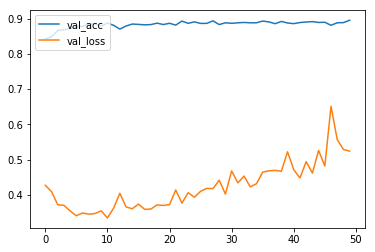

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_acc'])
plt.plot(history.history['val_loss'])
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()


In [31]:
print("Final train Accuracy : ", history.history["acc"][-1])
print("Final test Accuracy : ", history.history["val_acc"][-1])

Final train Accuracy :  0.95056665
Final test Accuracy :  0.8954
